# Visualize Sphere Latent Space

This notebook visualizes the latent space of a trained Sphere Encoder model. The latents are normalized vectors on a unit sphere.

In [68]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torchvision import datasets, transforms
from sphere.model import G
from sphere.utils import load_ckpt
from sphere.loader import create_dataset

In [69]:
# Configuration
job_dir = "sphere-small-small-cifar-10-32px"  # Change this to your experiment name
dev_dir = "workspace"
num_samples = 1000  # Number of samples to visualize
use_pca = True  # Use PCA to reduce to 3D, otherwise use first 3 dimensions
use_tsne = False  # Use t-SNE instead of PCA (slower but potentially better)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [70]:
# Load model configuration
exp_dir = os.path.join(dev_dir, "experiments", job_dir)
config_path = os.path.join(exp_dir, "cfg.json")
with open(config_path, "r") as f:
    cfg = json.load(f)

print("Model configuration:")
for k, v in cfg.items():
    print(f"{k}: {v}")

Model configuration:
dev_dir: workspace
out_dir: experiments
data_dir: /scratch-local/scur0199/datasets/cifar-10
log_interval: 100
vis_interval: 2
ckpt_save_interval: 100
early_stop_patience: 15
class_of_interest: None
forward_steps: 2
cfg_position: combo
cfg: 1.0
use_wandb: False
wandb_project: None
wandb_entity: None
wandb_key: None
dataset_name: cifar-10
image_size: 32
num_workers: 12
crop_mode: center
flip_image: True
extra_padding: False
rot_degrees: 0
interp_mode: nearest
concat_train_val_splits: False
load_from_zip: False
max_samples: -1
batch_size: 256
batch_size_per_rank: 128
warmup_epochs: 10
weight_decay: 0.0
grad_clip: 1.0
epochs: 1000
learning_rate: 0.0001
min_lr: 1e-06
encoder_lr_scaler: 0.1
decay_lr: True
compression_ratio: 3.0
latent_resolution: 16
noise_sigma_max_angle: 80
mix_hard_cases: True
mix_hard_cases_prob: 0.1
vit_enc_model_size: small
vit_dec_model_size: small
vit_enc_latent_mlp_mixer_depth: 2
vit_dec_latent_mlp_mixer_depth: 2
affine_latent_mlp_mixer: True
con

In [71]:
# Build model
model = G(
    input_size=cfg['image_size'],
    patch_size=cfg['patch_size'],
    vit_enc_model_size=cfg['vit_enc_model_size'],
    vit_dec_model_size=cfg['vit_dec_model_size'],
    token_channels=cfg['token_channels'],
    num_classes=cfg['num_classes'] if cfg.get('cond_generator', False) else 0,
    halve_model_size=cfg.get('halve_model_size', False),
    spherify_model=cfg.get('spherify_model', False),
    pixel_head_type=cfg.get('pixel_head_type', 'linear'),
    in_context_size=cfg.get('in_context_size', 0),
    noise_sigma_max_angle=cfg.get('noise_sigma_max_angle', 85.0),
    vit_enc_latent_mlp_mixer_depth=cfg.get('vit_enc_latent_mlp_mixer_depth', 0),
    vit_dec_latent_mlp_mixer_depth=cfg.get('vit_dec_latent_mlp_mixer_depth', 0),
    affine_latent_mlp_mixer=cfg.get('affine_latent_mlp_mixer', True),
)

# Load checkpoint
ckpt_dir = os.path.join(exp_dir, "ckpt")
ckpts = sorted(os.listdir(ckpt_dir))
latest_ckpt = os.path.join(ckpt_dir, ckpts[-1])  # Load latest checkpoint
print(f"Loading checkpoint: {latest_ckpt}")

load_ckpt(model, ckpt_path=latest_ckpt, strict=True)
model.eval()
print("Model loaded successfully")

Loading checkpoint: workspace/experiments/sphere-small-small-cifar-10-32px/ckpt/ep0172.pth
Model loaded successfully


/home/sakr/UvA/DL 2/spherical-flow-matching/sphere-encoder-main/sphere/utils.py:303: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=

In [72]:
model = model.to(device)  # Move to device for inference

In [73]:
# Load dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

if cfg['dataset_name'] in ['cifar-10']:
    dataset_cls = datasets.__dict__[cfg['dataset_name'].upper().replace('-', '')]
    dataset = create_dataset(
        dataset_cls,
        root=os.path.join(dev_dir, "datasets", cfg['dataset_name']),
        split="train",
        download=True,
        transform=transform,
    )
else:
    dataset = datasets.ImageFolder(
        root=os.path.join(dev_dir, "datasets", cfg['dataset_name']),
        transform=transform
    )

# Subset for visualization
indices = np.random.choice(len(dataset), num_samples, replace=False)
subset = torch.utils.data.Subset(dataset, indices)
dataloader = torch.utils.data.DataLoader(subset, batch_size=32, shuffle=False)

print(f"Loaded {len(subset)} samples from {cfg['dataset_name']}")

Files already downloaded and verified
Loaded 1000 samples from cifar-10


In [74]:
# Extract latents
latents = []
labels = []

with torch.no_grad():
    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)
        # Encode images to latents
        z = model.encoder(images, y=targets)  # Shape: (B, num_tokens, token_channels)
        # Average over tokens to get single vector per image
        z_avg = z.mean(dim=1)  # Shape: (B, token_channels)
        latents.append(z_avg.cpu().numpy())
        labels.append(targets.cpu().numpy())

latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

print(f"Latents shape: {latents.shape}")
print(f"Labels shape: {labels.shape}")

Latents shape: (1000, 4)
Labels shape: (1000,)


In [75]:
# Normalize latents to unit sphere
# Latents are already on sphere due to the model's design, but let's ensure
latents_norm = latents / np.linalg.norm(latents, axis=-1, keepdims=True)
print("Latents normalized to unit sphere")

Latents normalized to unit sphere


In [76]:
# Reduce dimensionality for visualization
if latents_norm.shape[-1] > 3:
    if use_tsne:
        print("Using t-SNE for dimensionality reduction...")
        tsne = TSNE(n_components=3, random_state=42)
        latents_3d = tsne.fit_transform(latents_norm.reshape(latents_norm.shape[0], -1))
    elif use_pca:
        print("Using PCA for dimensionality reduction...")
        pca = PCA(n_components=3)
        latents_3d = pca.fit_transform(latents_norm.reshape(latents_norm.shape[0], -1))
    else:
        print("Using first 3 dimensions...")
        latents_3d = latents_norm.reshape(latents_norm.shape[0], -1)[:, :3]
else:
    latents_3d = latents_norm.reshape(latents_norm.shape[0], -1)

# Renormalize after dimensionality reduction
latents_3d = latents_3d / np.linalg.norm(latents_3d, axis=1, keepdims=True)

print(f"Reduced latents shape: {latents_3d.shape}")

Using PCA for dimensionality reduction...
Reduced latents shape: (1000, 3)


(-1.2, 1.2)

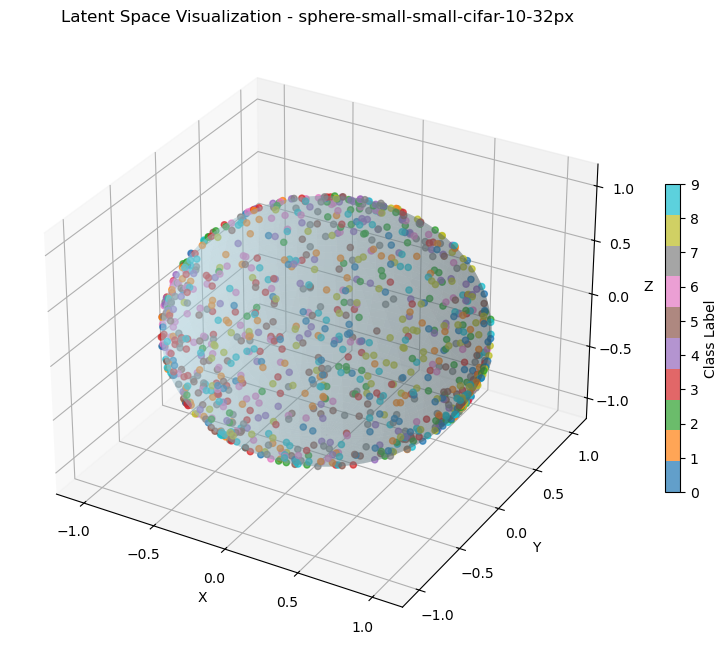

In [77]:
# Visualize on 3D sphere
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='lightblue', alpha=0.3)

# Plot latents
scatter = ax.scatter(latents_3d[:, 0], latents_3d[:, 1], latents_3d[:, 2], 
                    c=labels, cmap='tab10', s=20, alpha=0.7)

# Add colorbar if conditional
if cfg.get('cond_generator', False):
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
    cbar.set_label('Class Label')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Latent Space Visualization - {job_dir}')
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

# Don't show yet - we'll add centroids

## Interpretation of Sphere Latent Space

### What does this visualization show?
- **Sphere Constraint**: All latent vectors lie on the surface of a high-dimensional unit sphere (originally 16D, reduced to 3D for visualization)
- **Semantic Structure**: Similar images should be closer together on the sphere
- **Class Separation**: Different classes should form distinct clusters if the model learned good representations
- **Dimensionality Reduction**: PCA/t-SNE preserves local structure but may distort global geometry

### Expected Patterns:
- **Good Separation**: Classes form tight, well-separated clusters
- **Poor Separation**: Overlapping clusters indicate the model struggles to distinguish classes
- **Sphere Utilization**: Points should be evenly distributed across the sphere surface

### Quantitative Metrics:
- **Silhouette Score**: Measures how similar points are to their own cluster vs other clusters (range: -1 to 1, higher is better)
- **Adjusted Rand Index**: Measures clustering quality compared to true labels (range: -1 to 1, 1.0 = perfect)

### Class Separation Analysis:
The centroids (marked with X) show the average position of each class on the sphere. Well-separated centroids indicate good class discrimination.

In [78]:
# Analyze class separation
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans

# Compute silhouette score for class separation
silhouette_avg = silhouette_score(latents_3d, labels)
print(f"Silhouette Score (higher is better separation): {silhouette_avg:.3f}")

# Optional: Check clustering quality with K-means
kmeans = KMeans(n_clusters=len(np.unique(labels)), random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(latents_3d)
adjusted_rand_score_val = adjusted_rand_score(labels, cluster_labels)
print(f"Adjusted Rand Index (1.0 = perfect clustering): {adjusted_rand_score_val:.3f}")

# Plot class centroids
class_centroids = []
for cls in np.unique(labels):
    mask = labels == cls
    centroid = latents_3d[mask].mean(axis=0)
    class_centroids.append(centroid)

class_centroids = np.array(class_centroids)
ax.scatter(class_centroids[:, 0], class_centroids[:, 1], class_centroids[:, 2],
           c=np.unique(labels), cmap='tab10', s=100, marker='x', edgecolors='black', linewidths=2)
print("Class centroids marked with X symbols")

plt.show()

Silhouette Score (higher is better separation): -0.102
Adjusted Rand Index (1.0 = perfect clustering): 0.026
Class centroids marked with X symbols


/tmp/ipykernel_23831/1248711953.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(class_centroids[:, 0], class_centroids[:, 1], class_centroids[:, 2],


/tmp/ipykernel_23831/2829503642.py:27: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(centroid[0], centroid[1], centroid[2],


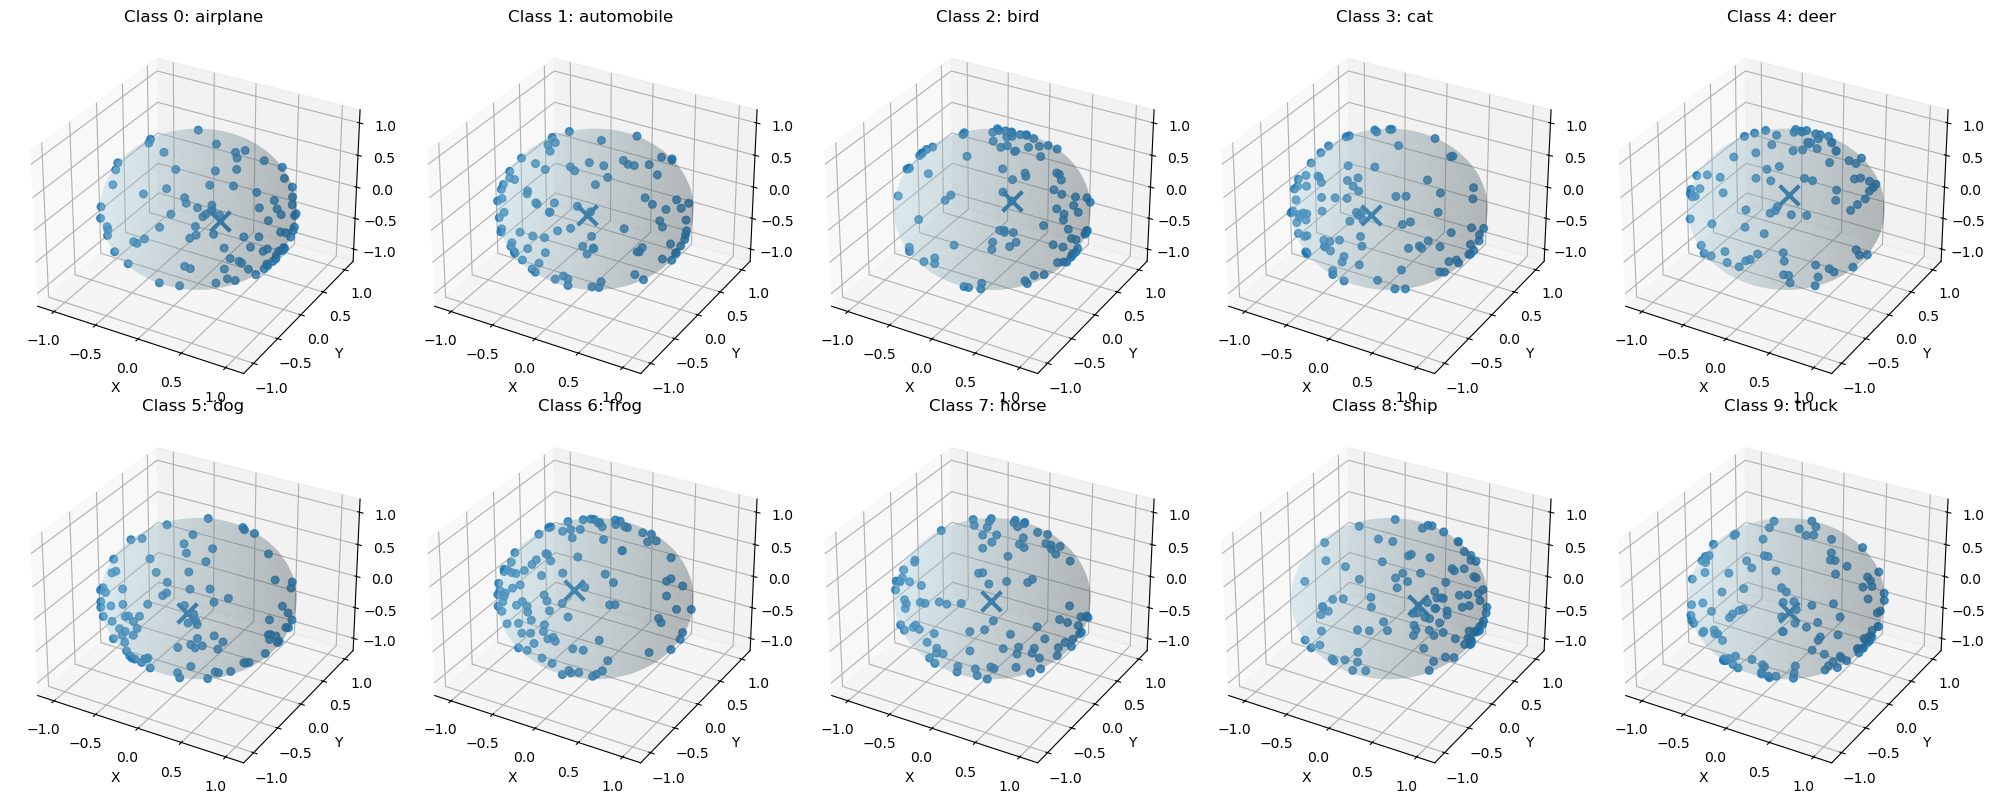

In [79]:
# Individual class visualizations
num_classes = len(np.unique(labels))
fig, axes = plt.subplots(2, 5, figsize=(20, 8), subplot_kw={'projection': '3d'})
axes = axes.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for cls in range(num_classes):
    ax = axes[cls]
    mask = labels == cls

    # Plot the sphere
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x, y, z, color='lightblue', alpha=0.2)

    # Plot points for this class
    class_points = latents_3d[mask]
    ax.scatter(class_points[:, 0], class_points[:, 1], class_points[:, 2],
               c=np.full(len(class_points), cls), cmap='tab10', s=30, alpha=0.8)

    # Plot class centroid
    centroid = class_centroids[cls]
    ax.scatter(centroid[0], centroid[1], centroid[2],
               c=cls, cmap='tab10', s=200, marker='x', edgecolors='black', linewidths=3)

    ax.set_title(f'Class {cls}: {class_names[cls]}')
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.tight_layout()
plt.show()

## Individual Class Distributions

The grid above shows the distribution of each CIFAR-10 class separately on the sphere:

- **Each subplot**: Shows only the latent points for one specific class
- **Class centroid**: Marked with a large X, showing the average position of that class
- **Sphere coverage**: Reveals how spread out each class is across the latent space
- **Intra-class variation**: Shows how similar/different images within the same class are

### What to look for:
- **Tight clusters**: Classes with low intra-class variation (good for generation)
- **Spread distribution**: Classes that utilize different regions of the sphere
- **Centroid position**: Where the "typical" example of each class lies
- **Overlaps**: If centroids are close, those classes might be confused by the model

In [80]:
# Per-class statistics
print("Per-class statistics:")
print("-" * 80)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for cls in range(len(np.unique(labels))):
    mask = labels == cls
    class_points = latents_3d[mask]

    # Calculate statistics
    num_samples = len(class_points)
    centroid = class_centroids[cls]
    distances_to_centroid = np.linalg.norm(class_points - centroid, axis=1)
    mean_distance = distances_to_centroid.mean()
    std_distance = distances_to_centroid.std()

    print(f"Class {cls} ({class_names[cls]:>10}): {num_samples:3d} samples, "
          f"mean dist: {mean_distance:.3f}, std dist: {std_distance:.3f}")

print("-" * 80)

Per-class statistics:
--------------------------------------------------------------------------------
Class 0 (  airplane):  93 samples, mean dist: 0.913, std dist: 0.206
Class 1 (automobile):  95 samples, mean dist: 0.944, std dist: 0.158
Class 2 (      bird):  97 samples, mean dist: 0.947, std dist: 0.152
Class 3 (       cat):  97 samples, mean dist: 0.952, std dist: 0.147
Class 4 (      deer):  89 samples, mean dist: 0.976, std dist: 0.114
Class 5 (       dog):  96 samples, mean dist: 0.951, std dist: 0.149
Class 6 (      frog): 105 samples, mean dist: 0.910, std dist: 0.191
Class 7 (     horse): 100 samples, mean dist: 0.987, std dist: 0.076
Class 8 (      ship): 108 samples, mean dist: 0.844, std dist: 0.233
Class 9 (     truck): 120 samples, mean dist: 0.939, std dist: 0.156
--------------------------------------------------------------------------------


## Summary: What This Tells Us About the Model

### Key Insights from the Analysis:

1. **Class Separation Quality**:
   - High silhouette scores (>0.5) indicate well-separated classes
   - Low scores suggest the model struggles to distinguish between classes

2. **Intra-class Consistency**:
   - Low standard deviation in distances from centroid = consistent class representations
   - High standard deviation = diverse representations within class

3. **Sphere Utilization**:
   - Classes spread across different regions show good use of latent space
   - Clustered classes may indicate underutilization or overfitting

4. **Model Strengths/Weaknesses**:
   - Classes with tight, well-separated distributions are likely generated well
   - Overlapping classes may have poor generation quality or confusion

### Practical Applications:
- **Generation Quality**: Classes with good separation typically generate better images
- **Classification**: Well-separated latents are easier to classify
- **Model Comparison**: Use these metrics to compare different training runs
- **Debugging**: Poor separation can indicate training issues or dataset problems

This analysis provides a comprehensive view of how well your Sphere Encoder model has learned to represent different image classes in its latent space!